# Laboratorio 4 — Análisis de datos geoespaciales

**Curso:** CC3084 · Data Science · Semestre 02, 2026 · Universidad del Valle de Guatemala

| Integrante | Ejercicios | Responsabilidad |
|---|---:|---|
| **Daniel Chet** | 1–4 | openEO, descarga, índices y análisis temporal (avance) |
| **Javier Linares** | 5–6 | análisis espacial y correlaciones |
| **Dulce Ambrosio** | 7–8 | comparación entre lagos y análisis adicionales |

Este cuaderno desarrolla los ejercicios del laboratorio para los lagos **Atitlán** y **Amatitlán**. El flujo consulta openEO, documenta la descarga de Sentinel-2 L1C, reproduce los índices espectrales, analiza la evolución temporal y espacial, estudia correlaciones y compara la extensión, persistencia, distribución y estacionalidad de la señal de cianobacterias.

> La clorofila-a obtenida es un **estimador satelital**. No mide toxicidad ni sustituye el muestreo de campo.

## 0. Configuración y reproducibilidad

El notebook busca primero datos dentro de esta versión (`data/raw` y `data/processed`). Para evitar duplicar más de 300 MB en esta copia local, si esas carpetas están vacías reutiliza los rasters de la versión original ubicada un nivel arriba. Todos los nuevos resúmenes y gráficos se guardan en `version_notebook/results/`.

In [1]:
import json
import math
import warnings
import zlib
from datetime import date, timedelta
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from IPython.display import display
from matplotlib.colors import BoundaryNorm
from rasterio.plot import plotting_extent

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False, "font.size": 10})
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd / "version_notebook"]
VERSION_ROOT = next(
    (candidate for candidate in candidates if (candidate / "codebook.md").exists()),
    None,
)
if VERSION_ROOT is None:
    raise FileNotFoundError("Ejecute el notebook desde version_notebook/ o desde la raíz del laboratorio.")

LEGACY_ROOT = VERSION_ROOT.parent
PRIMARY_RAW = VERSION_ROOT / "data" / "raw"
PRIMARY_INDEX = VERSION_ROOT / "data" / "processed" / "indices"
RESULTS_DIR = VERSION_ROOT / "results"
for directory in (PRIMARY_RAW, PRIMARY_INDEX, RESULTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

legacy_raw = LEGACY_ROOT / "datos" / "raster"
legacy_index = LEGACY_ROOT / "resultados" / "indices"
RAW_DIR = PRIMARY_RAW if any(PRIMARY_RAW.rglob("*.tif")) else legacy_raw
INDEX_DIR = PRIMARY_INDEX if any(PRIMARY_INDEX.rglob("*.tif")) else legacy_index

BACKEND_URL = "https://openeo.dataspace.copernicus.eu"
COLLECTION_ID = "SENTINEL2_L1C"
RESOLUTION_METERS = 20
BANDS = ("B02", "B03", "B04", "B05", "B07", "B08", "B8A", "B11", "B12")
INDEX_BANDS = ("NDVI", "NDWI", "NDCI", "CYANO_CHLA", "FAI", "WATER_MASK")

print(f"Raíz de la versión notebook: {VERSION_ROOT}")
print(f"Rasters fuente: {RAW_DIR}")
print(f"Índices procesados: {INDEX_DIR}")
print(f"Nuevos resultados: {RESULTS_DIR}")

Raíz de la versión notebook: C:\UVG\Semestre8\CC3084 - Data Science\Tareas\Lab4-DatosGeoespaciales\version_notebook
Rasters fuente: C:\UVG\Semestre8\CC3084 - Data Science\Tareas\Lab4-DatosGeoespaciales\datos\raster
Índices procesados: C:\UVG\Semestre8\CC3084 - Data Science\Tareas\Lab4-DatosGeoespaciales\resultados\indices
Nuevos resultados: C:\UVG\Semestre8\CC3084 - Data Science\Tareas\Lab4-DatosGeoespaciales\version_notebook\results


## 1. Conexión con la API openEO

Se verifica el catálogo público de Copernicus Data Space Ecosystem. Esta consulta no necesita credenciales; la autenticación OIDC se requiere únicamente al ejecutar trabajos de descarga.

In [2]:
evidence = {}
try:
    import openeo

    public_connection = openeo.connect(BACKEND_URL)
    collection_ids = public_connection.list_collection_ids()
    if COLLECTION_ID not in collection_ids:
        raise RuntimeError(f"El catálogo no contiene {COLLECTION_ID}.")
    evidence = {
        "backend": BACKEND_URL,
        "coleccion": COLLECTION_ID,
        "estado": "conexión pública correcta",
        "bandas_requeridas": ", ".join(BANDS),
        "fuente_evidencia": "consulta en línea",
    }
except Exception as exc:
    fallback = LEGACY_ROOT / "resultados" / "conexion_openeo.json"
    if not fallback.exists():
        raise
    saved = json.loads(fallback.read_text(encoding="utf-8"))
    evidence = {
        "backend": saved["backend"],
        "coleccion": saved["collection"],
        "estado": saved["status"],
        "bandas_requeridas": ", ".join(saved["required_bands"]),
        "fuente_evidencia": f"evidencia guardada; consulta actual falló: {type(exc).__name__}",
    }

(RESULTS_DIR / "conexion_openeo.json").write_text(
    json.dumps(evidence, ensure_ascii=False, indent=2), encoding="utf-8"
)
display(pd.DataFrame([evidence]))

,backend,coleccion,estado,bandas_requeridas,fuente_evidencia
0,https://openeo.dataspace.copernicus.eu,SENTINEL2_L1C,conexión pública correcta,"B02, B03, B04, B05, B07, B08, B8A, B11, B12",consulta en línea


**Resultado del inciso 1.** El endpoint respondió y anunció la colección Sentinel-2 L1C. La autenticación no se incrusta en el notebook: openEO abre el flujo OIDC en el navegador y conserva cualquier token fuera del proyecto.

## 2. Áreas, fechas oficiales y descarga mínima

Se usan literalmente los rectángulos, fechas, satélites y porcentajes de nubosidad dados en el enunciado. Las nueve bandas elegidas son las mínimas para reproducir NDVI, NDWI, NDCI, FAI y la máscara de agua completa.

In [3]:
LAKES = {
    "amatitlan": {
        "name": "Amatitlán",
        "bbox": {"west": -90.638065, "east": -90.512924, "south": 14.412347, "north": 14.493799},
        "observations": [
            ("2025-01-28", 0.06, "Sentinel-2B", ""),
            ("2025-04-15", 0.09, "Sentinel-2A", ""),
            ("2025-04-28", 1.03, "Sentinel-2B", ""),
            ("2025-11-24", 0.50, "Sentinel-2B", ""),
            ("2026-01-08", 0.77, "Sentinel-2C", ""),
            ("2026-02-02", 0.39, "Sentinel-2B", ""),
            ("2026-02-07", 0.02, "Sentinel-2C", "Cobertura válida parcial (~57.1%)."),
            ("2026-03-29", 0.01, "Sentinel-2C", ""),
            ("2026-04-13", 0.09, "Sentinel-2B", ""),
            ("2026-04-28", 4.96, "Sentinel-2C", ""),
            ("2026-06-19", 13.00, "Sentinel-2A", ""),
        ],
    },
    "atitlan": {
        "name": "Atitlán",
        "bbox": {"west": -91.326256, "east": -91.071510, "south": 14.594800, "north": 14.750979},
        "observations": [
            ("2025-01-18", 0.02, "Sentinel-2B", ""),
            ("2025-04-13", 0.54, "Sentinel-2C", ""),
            ("2025-05-13", 4.37, "Sentinel-2C", ""),
            ("2025-07-17", 3.57, "Sentinel-2A", ""),
            ("2025-11-21", 3.15, "Sentinel-2A", ""),
            ("2025-12-29", 3.17, "Sentinel-2C", ""),
            ("2026-02-12", 0.04, "Sentinel-2B", ""),
            ("2026-03-24", 3.17, "Sentinel-2B", ""),
            ("2026-04-13", 0.01, "Sentinel-2B", ""),
            ("2026-04-28", 4.96, "Sentinel-2C", ""),
            ("2026-07-22", 4.02, "Sentinel-2B", ""),
        ],
    },
}

observation_rows = []
for lake_id, lake in LAKES.items():
    for day, clouds, satellite, note in lake["observations"]:
        observation_rows.append({
            "lago": lake["name"], "lago_id": lake_id, "fecha": day,
            "satelite": satellite, "nubosidad_pct": clouds, "nota": note,
        })
official_dates = pd.DataFrame(observation_rows)
display(official_dates)
print(f"Total: {len(official_dates)} observaciones; bandas: {', '.join(BANDS)}")

,lago,lago_id,fecha,satelite,nubosidad_pct,nota
0,Amatitlán,amatitlan,2025-01-28,Sentinel-2B,0.0600,
1,Amatitlán,amatitlan,2025-04-15,Sentinel-2A,0.0900,
2,Amatitlán,amatitlan,2025-04-28,Sentinel-2B,1.0300,
3,Amatitlán,amatitlan,2025-11-24,Sentinel-2B,0.5000,
4,Amatitlán,amatitlan,2026-01-08,Sentinel-2C,0.7700,
5,Amatitlán,amatitlan,2026-02-02,Sentinel-2B,0.3900,
6,Amatitlán,amatitlan,2026-02-07,Sentinel-2C,0.0200,Cobertura válida parcial (~57.1%).
7,Amatitlán,amatitlan,2026-03-29,Sentinel-2C,0.0100,
8,Amatitlán,amatitlan,2026-04-13,Sentinel-2B,0.0900,
9,Amatitlán,amatitlan,2026-04-28,Sentinel-2C,4.9600,


Total: 22 observaciones; bandas: B02, B03, B04, B05, B07, B08, B8A, B11, B12


In [4]:
def download_official_rasters(lake_filter=None, force=False):
    # Descarga un GeoTIFF multibanda por fecha. Ejecutar solo cuando se necesiten los datos.
    import openeo

    connection = openeo.connect(BACKEND_URL)
    connection.authenticate_oidc(store_refresh_token=True, max_poll_time=600)
    for lake_id, lake in LAKES.items():
        if lake_filter and lake_id != lake_filter:
            continue
        destination_dir = PRIMARY_RAW / lake_id
        destination_dir.mkdir(parents=True, exist_ok=True)
        for day, _, _, _ in lake["observations"]:
            destination = destination_dir / f"{day}.tif"
            if destination.exists() and not force:
                print(f"[omitido] {destination.name}")
                continue
            start = date.fromisoformat(day)
            cube = connection.load_collection(
                COLLECTION_ID,
                spatial_extent=lake["bbox"],
                temporal_extent=[start.isoformat(), (start + timedelta(days=1)).isoformat()],
                bands=list(BANDS),
                max_cloud_cover=100,
            )
            cube = cube.reduce_dimension(dimension="t", reducer="median")
            cube = cube.resample_spatial(resolution=RESOLUTION_METERS, method="bilinear")
            cube.download(str(destination), format="GTiff")
            print(f"[descargado] {lake['name']} {day}")

# La descarga no se repite porque los 22 GeoTIFF ya están disponibles localmente.
availability = []
for lake_id, lake in LAKES.items():
    found = len(list((RAW_DIR / lake_id).glob("*.tif")))
    availability.append({"lago": lake["name"], "esperados": 11, "encontrados": found})
availability = pd.DataFrame(availability)
display(availability)
assert (availability["encontrados"] == availability["esperados"]).all()

,lago,esperados,encontrados
0,Amatitlán,11,11
1,Atitlán,11,11


## 3. Cálculo de NDVI, NDWI y estimador de cianobacterias

La ecuación implementada reproduce el **código** del evalscript Cyanobacteria Chlorophyll-a NDCI L1C. Aunque la descripción de la página menciona otra forma funcional, el script publicado usa el polinomio cúbico que aparece abajo. Los resultados se limitan a 0–500 mg/m³ y solo se conservan sobre la máscara de agua.

In [5]:
def normalized_difference(a, b):
    denominator = a + b
    result = np.full(np.broadcast_shapes(a.shape, b.shape), np.nan, dtype=np.float32)
    return np.divide(a - b, denominator, out=result, where=np.abs(denominator) > 1e-8)


def calculate_indices(bands, valid=None):
    arrays = {name: np.asarray(bands[name], dtype=np.float32) for name in BANDS}
    if valid is None:
        valid = np.logical_and.reduce([np.isfinite(array) for array in arrays.values()])

    blue, green, red = arrays["B02"], arrays["B03"], arrays["B04"]
    red_edge, red_edge_3 = arrays["B05"], arrays["B07"]
    nir, narrow_nir = arrays["B08"], arrays["B8A"]
    swir1, swir2 = arrays["B11"], arrays["B12"]

    ndvi = normalized_difference(nir, red)
    ndwi = normalized_difference(green, nir)
    mndwi = normalized_difference(green, swir1)
    ndwi_leaves = normalized_difference(nir, swir1)
    aweish = blue + 2.5 * green - 1.5 * (nir + swir1) - 0.25 * swir2
    aweinsh = 4.0 * (green - swir1) - (0.25 * nir + 2.75 * swir1)
    dbsi = normalized_difference(swir1, green) - ndvi
    water = (
        (mndwi > 0.42) | (ndwi > 0.4) | (aweinsh > 0.1879)
        | (aweish > 0.1112) | (ndvi < -0.2) | (ndwi_leaves > 1.0)
    )
    water &= ~((aweinsh <= -0.03) | (dbsi > 0.0))
    water &= valid

    fai = red_edge_3 - red - (narrow_nir - red) * ((783.0 - 665.0) / (865.0 - 665.0))
    ndci = normalized_difference(red_edge, red)
    cyano = np.clip(826.57 * ndci**3 - 176.43 * ndci**2 + 19.0 * ndci + 4.071, 0, 500)

    water_only = lambda values: np.where(water, values, np.nan).astype(np.float32)
    return {
        "NDVI": water_only(ndvi), "NDWI": water_only(ndwi),
        "NDCI": water_only(ndci), "CYANO_CHLA": water_only(cyano),
        "FAI": water_only(fai),
        "WATER_MASK": np.where(valid, water.astype(np.float32), np.nan),
    }


def process_source_raster(source, destination, lake_name, day):
    with rasterio.open(source) as src:
        stack = src.read().astype(np.float32)
        profile = src.profile.copy()
        descriptions = list(src.descriptions)
        nodata = src.nodata
    if stack.shape[0] != len(BANDS):
        raise ValueError(f"{source}: se esperaban {len(BANDS)} bandas.")
    valid = np.logical_and.reduce([np.isfinite(layer) for layer in stack])
    if nodata is not None and np.isfinite(nodata):
        valid &= np.logical_and.reduce([layer != nodata for layer in stack])
    valid &= np.any(stack != 0, axis=0)
    if np.nanpercentile(stack[:, valid], 99) > 2:
        stack *= 0.0001
    names = [next((b for b in BANDS if str(d).upper().startswith(b)), "") for d in descriptions]
    if set(names) != set(BANDS):
        names = list(BANDS)
    indices = calculate_indices(dict(zip(names, stack)), valid)

    destination.parent.mkdir(parents=True, exist_ok=True)
    for key in ("blockxsize", "blockysize", "tiled"):
        profile.pop(key, None)
    profile.update(driver="GTiff", dtype="float32", count=6, nodata=np.nan, compress="deflate")
    with rasterio.open(destination, "w", **profile) as dst:
        for band_number, name in enumerate(INDEX_BANDS, start=1):
            dst.write(indices[name], band_number)
            dst.set_band_description(band_number, name)
        dst.update_tags(lake=lake_name, source_date=day, source_collection=COLLECTION_ID)
    return destination


# Si se parte de una descarga nueva, esta celda crea únicamente los productos faltantes.
if not any(INDEX_DIR.rglob("*_indices.tif")):
    INDEX_DIR = PRIMARY_INDEX
    for lake_id, lake in LAKES.items():
        for day, _, _, _ in lake["observations"]:
            source = RAW_DIR / lake_id / f"{day}.tif"
            destination = INDEX_DIR / lake_id / f"{day}_indices.tif"
            if source.exists() and not destination.exists():
                process_source_raster(source, destination, lake["name"], day)

validation_rows = []
products = {}
for lake_id, lake in LAKES.items():
    signatures = set()
    products[lake_id] = []
    for day, _, _, _ in lake["observations"]:
        path = INDEX_DIR / lake_id / f"{day}_indices.tif"
        if not path.exists():
            raise FileNotFoundError(path)
        with rasterio.open(path) as src:
            signatures.add((src.width, src.height, tuple(src.transform), str(src.crs)))
            descriptions = tuple(src.descriptions)
        if descriptions != INDEX_BANDS:
            raise ValueError(f"Bandas inesperadas en {path.name}: {descriptions}")
        products[lake_id].append((pd.Timestamp(day), path))
    validation_rows.append({
        "lago": lake["name"], "productos": len(products[lake_id]),
        "grillas_distintas": len(signatures), "bandas_por_producto": len(INDEX_BANDS),
    })
validation = pd.DataFrame(validation_rows)
display(validation)
assert (validation["productos"] == 11).all() and (validation["grillas_distintas"] == 1).all()

,lago,productos,grillas_distintas,bandas_por_producto
0,Amatitlán,11,1,6
1,Atitlán,11,1,6


In [6]:
def read_index_product(path):
    with rasterio.open(path) as src:
        descriptions = list(src.descriptions)
        arrays = {
            name: src.read(descriptions.index(name) + 1).astype(np.float32)
            for name in INDEX_BANDS
        }
        profile = {"transform": src.transform, "crs": src.crs}
        pixel_area_km2 = abs(src.transform.a * src.transform.e) / 1_000_000
    return arrays, profile, pixel_area_km2


summary_rows = []
for lake_id, dated_products in products.items():
    lake = LAKES[lake_id]
    metadata = {day: (clouds, satellite, note) for day, clouds, satellite, note in lake["observations"]}
    for day, path in dated_products:
        arrays, profile, pixel_area_km2 = read_index_product(path)
        cyano = arrays["CYANO_CHLA"]
        valid_count = int(np.count_nonzero(np.isfinite(cyano)))
        clouds, satellite, note = metadata[day.strftime("%Y-%m-%d")]
        summary_rows.append({
            "lago": lake["name"], "lago_id": lake_id, "fecha": day,
            "satelite": satellite, "nubosidad_pct": clouds, "nota": note,
            "cyano_promedio_mg_m3": float(np.nanmean(cyano)),
            "cyano_mediana_mg_m3": float(np.nanmedian(cyano)),
            "cyano_p95_mg_m3": float(np.nanpercentile(cyano, 95)),
            "ndvi_promedio_agua": float(np.nanmean(arrays["NDVI"])),
            "ndwi_promedio_agua": float(np.nanmean(arrays["NDWI"])),
            "pixeles_agua_validos": valid_count,
            "area_agua_valida_km2": valid_count * pixel_area_km2,
        })

summary = pd.DataFrame(summary_rows).sort_values(["lago", "fecha"]).reset_index(drop=True)
summary.to_csv(RESULTS_DIR / "resumen_temporal.csv", index=False, date_format="%Y-%m-%d")
display(summary)
print(f"Resumen construido directamente desde {len(summary)} productos raster.")

,lago,lago_id,fecha,satelite,nubosidad_pct,nota,cyano_promedio_mg_m3,cyano_mediana_mg_m3,cyano_p95_mg_m3,ndvi_promedio_agua,ndwi_promedio_agua,pixeles_agua_validos,area_agua_valida_km2
0,Amatitlán,amatitlan,2025-01-28,Sentinel-2B,0.0600,,4.4304,4.4863,4.8036,-0.2225,0.4594,36693,14.6772
1,Amatitlán,amatitlan,2025-04-15,Sentinel-2A,0.0900,,4.5292,4.6079,6.4335,-0.1025,0.2928,36320,14.5280
2,Amatitlán,amatitlan,2025-04-28,Sentinel-2B,1.0300,,5.7235,4.8923,11.1137,-0.0793,0.2901,36312,14.5248
3,Amatitlán,amatitlan,2025-11-24,Sentinel-2B,0.5000,,4.6726,4.0074,6.2128,-0.2114,0.4311,36438,14.5752
4,Amatitlán,amatitlan,2026-01-08,Sentinel-2C,0.7700,,6.6495,4.8901,13.1327,-0.1028,0.3544,36677,14.6708
5,Amatitlán,amatitlan,2026-02-02,Sentinel-2B,0.3900,,4.2923,4.4070,4.7496,-0.1052,0.2918,36036,14.4144
6,Amatitlán,amatitlan,2026-02-07,Sentinel-2C,0.0200,Cobertura válida parcial (~57.1%).,4.3059,4.4552,4.7803,-0.1458,0.3630,36598,14.6392
7,Amatitlán,amatitlan,2026-03-29,Sentinel-2C,0.0100,,6.4130,5.2338,15.3678,-0.0966,0.3173,36734,14.6936
8,Amatitlán,amatitlan,2026-04-13,Sentinel-2B,0.0900,,6.6974,6.3950,9.6077,-0.0649,0.2957,36895,14.7580
9,Amatitlán,amatitlan,2026-04-28,Sentinel-2C,4.9600,,9.8728,6.3633,26.0064,0.0213,0.2285,35009,14.0036


Resumen construido directamente desde 22 productos raster.


## 4. Evolución temporal

Se grafica el promedio de clorofila-a estimada para cada fecha. El percentil 75 (Q75) de cada lago se usa únicamente para señalar sus observaciones relativamente altas.

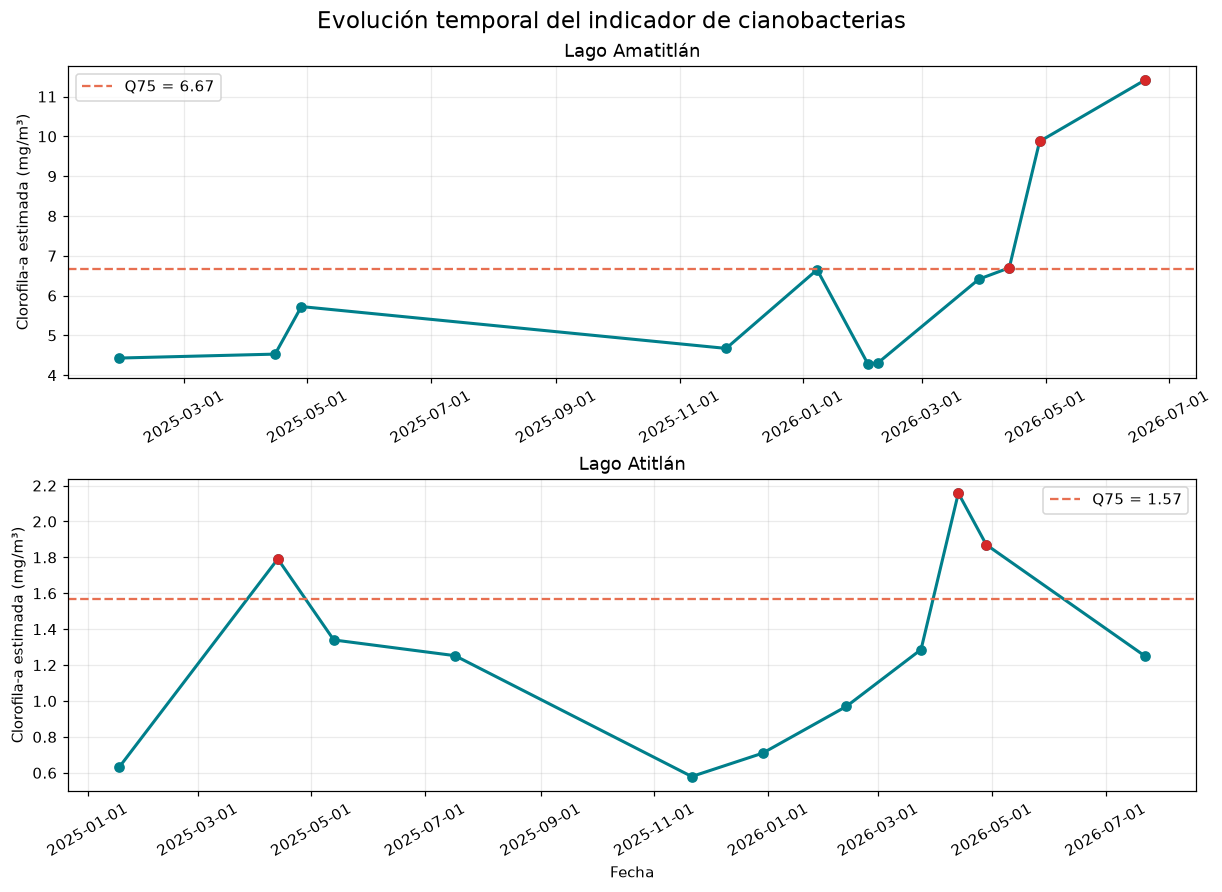

,lago,fecha,cyano_promedio_mg_m3,umbral_q75_mg_m3
0,Amatitlán,2026-04-13,6.6974,6.6735
1,Amatitlán,2026-04-28,9.8728,6.6735
2,Amatitlán,2026-06-19,11.4117,6.6735
3,Atitlán,2025-04-13,1.7913,1.5657
4,Atitlán,2026-04-13,2.1578,1.5657
5,Atitlán,2026-04-28,1.8705,1.5657


In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), constrained_layout=True)
critical_rows = []
for ax, (lake_id, group) in zip(axes, summary.groupby("lago_id", sort=True)):
    group = group.sort_values("fecha")
    q75 = group["cyano_promedio_mg_m3"].quantile(0.75)
    critical = group[group["cyano_promedio_mg_m3"] >= q75]
    critical_rows.extend(critical.assign(umbral_q75_mg_m3=q75).to_dict("records"))
    ax.plot(group["fecha"], group["cyano_promedio_mg_m3"], marker="o", lw=2, color="#007f8b")
    ax.axhline(q75, color="#e76f51", linestyle="--", label=f"Q75 = {q75:.2f}")
    ax.scatter(critical["fecha"], critical["cyano_promedio_mg_m3"], color="#d62828", zorder=3)
    ax.set_title(f"Lago {LAKES[lake_id]['name']}")
    ax.set_ylabel("Clorofila-a estimada (mg/m³)")
    ax.grid(alpha=0.25)
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax.tick_params(axis="x", rotation=30)
axes[-1].set_xlabel("Fecha")
fig.suptitle("Evolución temporal del indicador de cianobacterias", fontsize=15)
fig.savefig(RESULTS_DIR / "04_evolucion_temporal.png", dpi=180, bbox_inches="tight")
plt.show()

critical_dates = pd.DataFrame(critical_rows)
display(critical_dates[["lago", "fecha", "cyano_promedio_mg_m3", "umbral_q75_mg_m3"]])

**Interpretación.** Amatitlán alcanzó el máximo el **19/06/2026** con **11.41 mg/m³**, mientras Atitlán alcanzó **2.16 mg/m³** el **13/04/2026**. La línea conecta fechas irregulares y no supone que el cambio haya sido continuo entre adquisiciones.

## 5. Análisis espacial — Javier Linares

Para cada lago se comparan las fechas de menor, mediana y mayor concentración promedio con una escala común. Después se calcula la diferencia espacial entre la fecha máxima y mínima y la frecuencia de píxeles sobre 20 mg/m³.

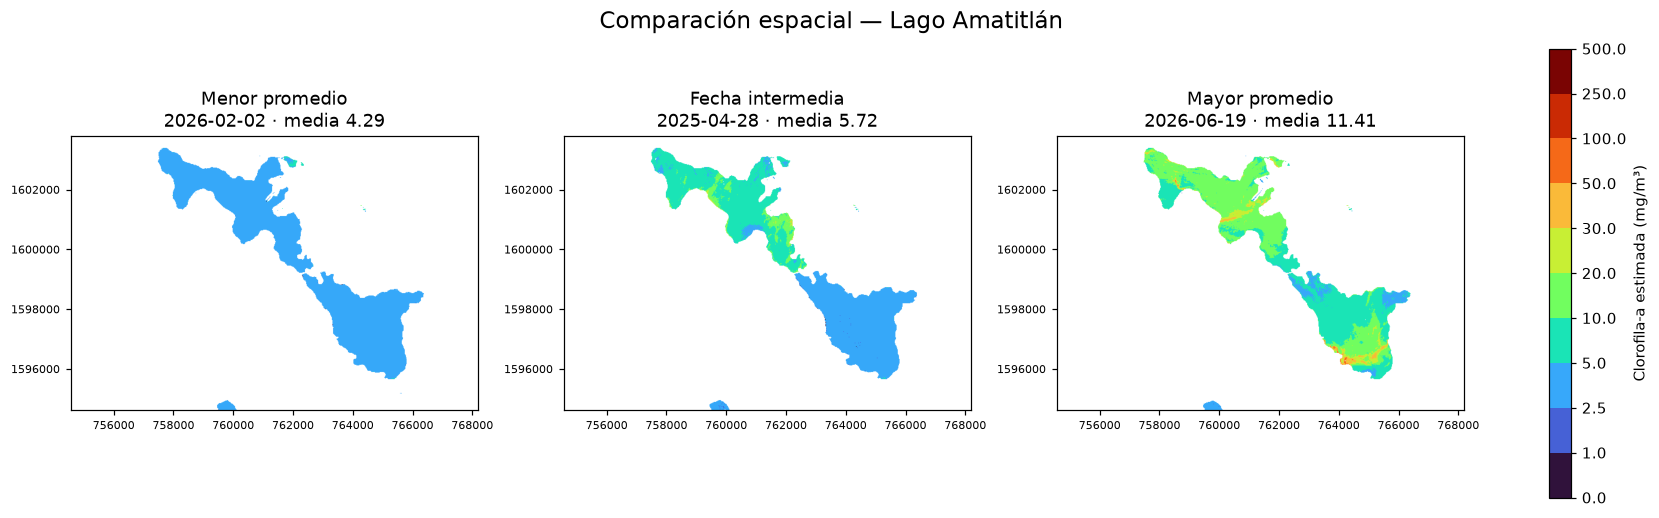

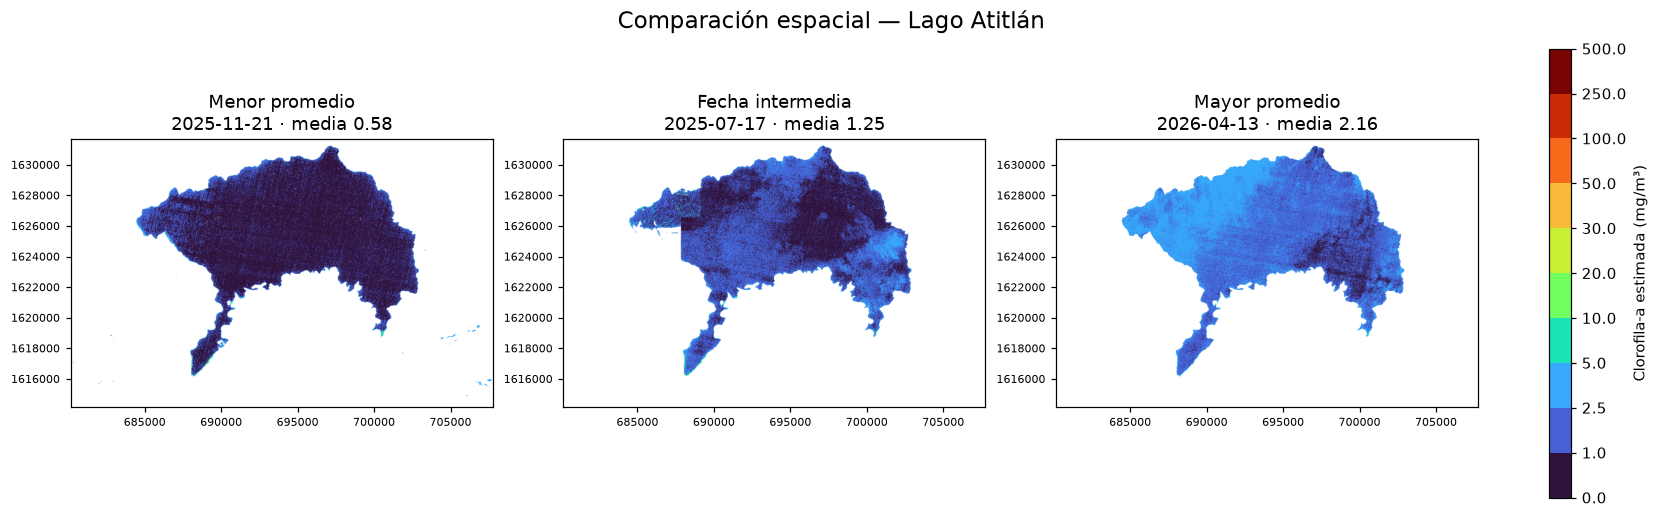

In [8]:
CYANO_BOUNDARIES = [0, 1, 2.5, 5, 10, 20, 30, 50, 100, 250, 500]
cyano_cmap = plt.get_cmap("turbo", len(CYANO_BOUNDARIES) - 1)
cyano_norm = BoundaryNorm(CYANO_BOUNDARIES, cyano_cmap.N, clip=True)

for lake_id, group in summary.groupby("lago_id", sort=True):
    ordered = group.sort_values("cyano_promedio_mg_m3").reset_index(drop=True)
    selected = [ordered.iloc[0], ordered.iloc[len(ordered) // 2], ordered.iloc[-1]]
    labels = ["Menor promedio", "Fecha intermedia", "Mayor promedio"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), constrained_layout=True)
    image = None
    for ax, row, label in zip(axes, selected, labels):
        path = INDEX_DIR / lake_id / f"{row['fecha']:%Y-%m-%d}_indices.tif"
        arrays, profile, _ = read_index_product(path)
        values = arrays["CYANO_CHLA"]
        extent = plotting_extent(values, transform=profile["transform"])
        image = ax.imshow(values, extent=extent, cmap=cyano_cmap, norm=cyano_norm)
        ax.set_title(f"{label}\n{row['fecha']:%Y-%m-%d} · media {row['cyano_promedio_mg_m3']:.2f}")
        ax.ticklabel_format(style="plain", useOffset=False)
        ax.tick_params(labelsize=7)
        ax.set_aspect("equal")
    fig.colorbar(image, ax=axes, label="Clorofila-a estimada (mg/m³)", ticks=CYANO_BOUNDARIES)
    fig.suptitle(f"Comparación espacial — Lago {LAKES[lake_id]['name']}", fontsize=15)
    fig.savefig(RESULTS_DIR / f"05_comparacion_{lake_id}.png", dpi=180, bbox_inches="tight")
    plt.show()

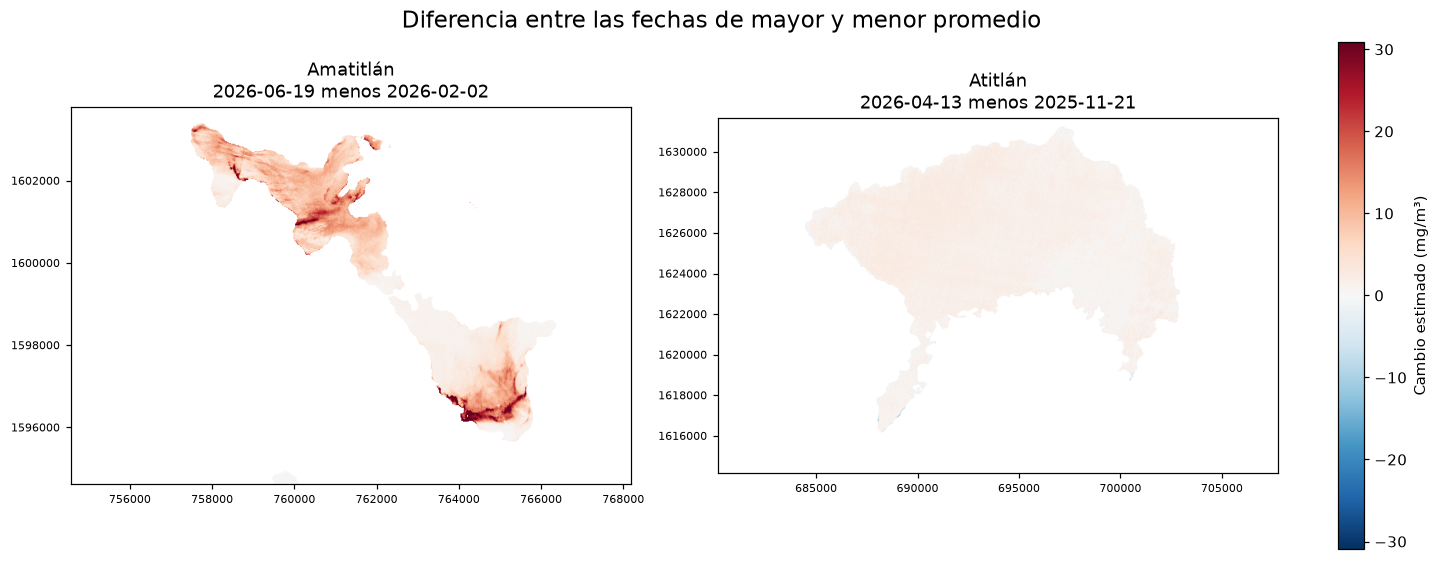

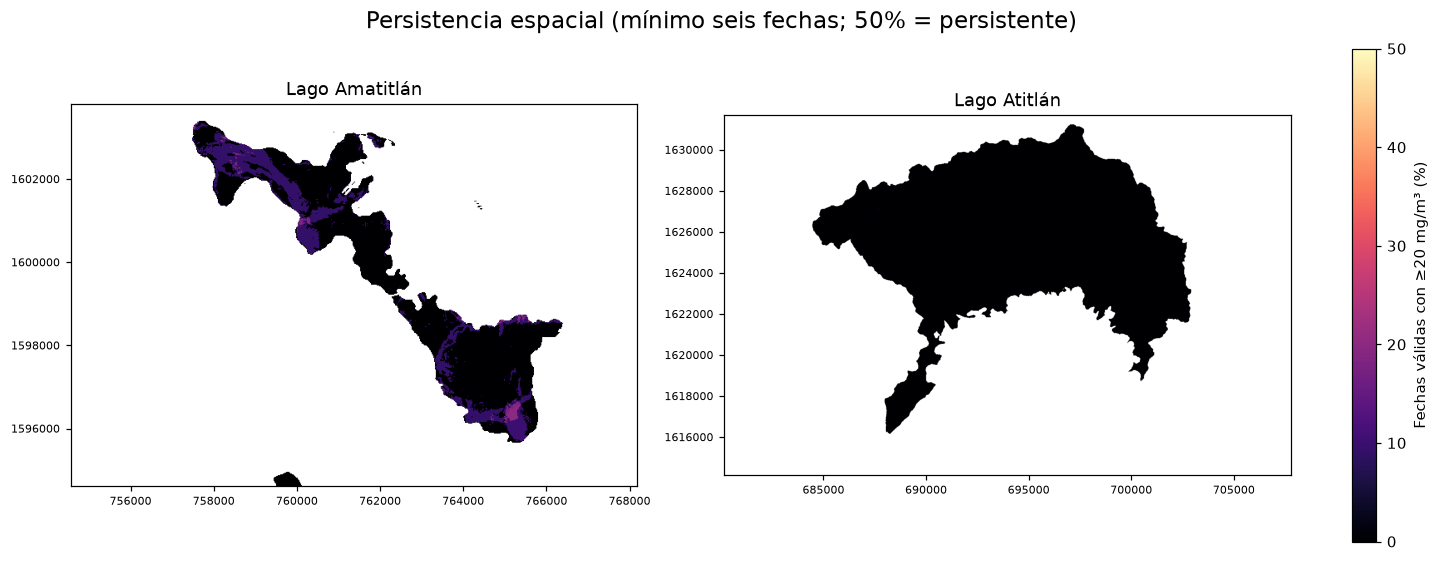

,lago,lago_id,zona,frecuencia_media_pct,area_persistente_km2
0,Amatitlán,amatitlan,Noroeste,3.4627,0.0000
1,Amatitlán,amatitlan,Noreste,0.5755,0.0000
2,Amatitlán,amatitlan,Suroeste,0.0000,0.0000
3,Amatitlán,amatitlan,Sureste,2.0993,0.0000
4,Amatitlán,amatitlan,Total,2.3818,0.0000
5,Atitlán,atitlan,Noroeste,0.0004,0.0000
6,Atitlán,atitlan,Noreste,0.0000,0.0000
7,Atitlán,atitlan,Suroeste,0.0030,0.0000
8,Atitlán,atitlan,Sureste,0.0036,0.0000
9,Atitlán,atitlan,Total,0.0007,0.0000


In [9]:
HIGH_THRESHOLD = 20.0
MIN_VALID_DATES = 6
PERSISTENT_PERCENT = 50.0
spatial_cache = {}
differences = []
persistence_rows = []

for lake_id, group in summary.groupby("lago_id", sort=True):
    low = group.loc[group["cyano_promedio_mg_m3"].idxmin()]
    high = group.loc[group["cyano_promedio_mg_m3"].idxmax()]
    low_arrays, _, _ = read_index_product(INDEX_DIR / lake_id / f"{low['fecha']:%Y-%m-%d}_indices.tif")
    high_arrays, profile, pixel_area = read_index_product(INDEX_DIR / lake_id / f"{high['fecha']:%Y-%m-%d}_indices.tif")
    both_valid = np.isfinite(low_arrays["CYANO_CHLA"]) & np.isfinite(high_arrays["CYANO_CHLA"])
    difference = np.where(both_valid, high_arrays["CYANO_CHLA"] - low_arrays["CYANO_CHLA"], np.nan)

    first_values, _, _ = read_index_product(products[lake_id][0][1])
    valid_count = np.zeros(first_values["CYANO_CHLA"].shape, dtype=np.uint16)
    high_count = np.zeros_like(valid_count)
    for _, path in products[lake_id]:
        arrays, _, _ = read_index_product(path)
        cyano = arrays["CYANO_CHLA"]
        valid = np.isfinite(cyano)
        valid_count += valid
        high_count += valid & (cyano >= HIGH_THRESHOLD)
    persistence = np.full(valid_count.shape, np.nan, dtype=np.float32)
    enough = valid_count >= MIN_VALID_DATES
    persistence[enough] = 100 * high_count[enough] / valid_count[enough]
    persistent = persistence >= PERSISTENT_PERCENT

    height, width = persistence.shape
    zones = {
        "Noroeste": (slice(0, height // 2), slice(0, width // 2)),
        "Noreste": (slice(0, height // 2), slice(width // 2, width)),
        "Suroeste": (slice(height // 2, height), slice(0, width // 2)),
        "Sureste": (slice(height // 2, height), slice(width // 2, width)),
    }
    for zone, slices in zones.items():
        zone_enough = enough[slices]
        zone_persistent = persistent[slices]
        persistence_rows.append({
            "lago": LAKES[lake_id]["name"], "lago_id": lake_id, "zona": zone,
            "frecuencia_media_pct": float(np.nanmean(persistence[slices][zone_enough])),
            "area_persistente_km2": int(np.count_nonzero(zone_persistent)) * pixel_area,
        })
    persistence_rows.append({
        "lago": LAKES[lake_id]["name"], "lago_id": lake_id, "zona": "Total",
        "frecuencia_media_pct": float(np.nanmean(persistence)),
        "area_persistente_km2": int(np.count_nonzero(persistent)) * pixel_area,
    })
    differences.append((lake_id, difference, profile, low, high))
    spatial_cache[lake_id] = {"persistence": persistence, "profile": profile}

vmax = max(2, max(float(np.nanpercentile(np.abs(item[1]), 99)) for item in differences))
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, (lake_id, difference, profile, low, high) in zip(axes, differences):
    extent = plotting_extent(difference, transform=profile["transform"])
    image = ax.imshow(difference, extent=extent, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_title(f"{LAKES[lake_id]['name']}\n{high['fecha']:%Y-%m-%d} menos {low['fecha']:%Y-%m-%d}")
    ax.ticklabel_format(style="plain", useOffset=False); ax.tick_params(labelsize=7)
fig.colorbar(image, ax=axes, label="Cambio estimado (mg/m³)")
fig.suptitle("Diferencia entre las fechas de mayor y menor promedio", fontsize=15)
fig.savefig(RESULTS_DIR / "05_diferencias.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for ax, (lake_id, item) in zip(axes, sorted(spatial_cache.items())):
    persistence = item["persistence"]
    extent = plotting_extent(persistence, transform=item["profile"]["transform"])
    image = ax.imshow(persistence, extent=extent, cmap="magma", vmin=0, vmax=50)
    ax.set_title(f"Lago {LAKES[lake_id]['name']}")
    ax.ticklabel_format(style="plain", useOffset=False); ax.tick_params(labelsize=7)
fig.colorbar(image, ax=axes, label="Fechas válidas con ≥20 mg/m³ (%)")
fig.suptitle("Persistencia espacial (mínimo seis fechas; 50% = persistente)", fontsize=15)
fig.savefig(RESULTS_DIR / "05_persistencia.png", dpi=180, bbox_inches="tight")
plt.show()

persistence_table = pd.DataFrame(persistence_rows)
persistence_table.to_csv(RESULTS_DIR / "persistencia_por_zona.csv", index=False)
display(persistence_table)

**Interpretación espacial.** En Amatitlán, la fecha máxima eleva ambos lóbulos y concentra focos en los extremos noroeste y sur; el cambio no es uniforme. Atitlán permanece mayormente en las clases inferiores. Ningún píxel de los dos lagos superó 20 mg/m³ en al menos la mitad de sus fechas válidas, por lo que no se identificaron focos estrictamente persistentes.

## 6. Correlaciones entre NDVI, NDWI y cianobacterias — Javier Linares

Se calculan Pearson y Spearman en dos niveles: (1) los 11 promedios por fecha de cada lago y (2) una muestra determinista de 5,000 píxeles por fecha. El segundo nivel conserva la alineación entre índices, pero sus píxeles no deben tratarse como réplicas independientes.

In [10]:
def average_rank(values):
    return pd.Series(np.asarray(values, dtype=float)).rank(method="average").to_numpy()


def correlation_pair(x, y):
    x, y = np.asarray(x).ravel(), np.asarray(y).ravel()
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    if len(x) < 3 or np.ptp(x) == 0 or np.ptp(y) == 0:
        return np.nan, np.nan, len(x)
    pearson = float(np.corrcoef(x, y)[0, 1])
    spearman = float(np.corrcoef(average_rank(x), average_rank(y))[0, 1])
    return pearson, spearman, len(x)


def deterministic_sample(arrays, sample_size, seed_text):
    valid = np.logical_and.reduce([np.isfinite(array) for array in arrays])
    positions = np.flatnonzero(valid)
    if len(positions) > sample_size:
        rng = np.random.default_rng(zlib.crc32(seed_text.encode("utf-8")))
        positions = rng.choice(positions, sample_size, replace=False)
    return tuple(array.ravel()[positions] for array in arrays)


correlation_rows = []
pooled_samples = {}
sample_by_date = {}
for lake_id, group in summary.groupby("lago_id", sort=True):
    pooled_samples[lake_id] = {"cyano": [], "NDVI": [], "NDWI": []}
    sample_by_date[lake_id] = {}
    for day, path in products[lake_id]:
        arrays, _, _ = read_index_product(path)
        cyano, ndvi, ndwi = deterministic_sample(
            [arrays["CYANO_CHLA"], arrays["NDVI"], arrays["NDWI"]],
            5000, f"{lake_id}-{day:%Y-%m-%d}",
        )
        pooled_samples[lake_id]["cyano"].append(cyano)
        pooled_samples[lake_id]["NDVI"].append(ndvi)
        pooled_samples[lake_id]["NDWI"].append(ndwi)
        sample_by_date[lake_id][day] = {"cyano": cyano, "NDVI": ndvi, "NDWI": ndwi}

    for variable, column in (("NDVI", "ndvi_promedio_agua"), ("NDWI", "ndwi_promedio_agua")):
        pearson, spearman, n = correlation_pair(group[column], group["cyano_promedio_mg_m3"])
        correlation_rows.append({
            "lago": LAKES[lake_id]["name"], "lago_id": lake_id,
            "nivel": "promedios temporales", "variable": variable,
            "n": n, "pearson_r": pearson, "spearman_rho": spearman,
        })
        pearson, spearman, n = correlation_pair(
            np.concatenate(pooled_samples[lake_id][variable]),
            np.concatenate(pooled_samples[lake_id]["cyano"]),
        )
        correlation_rows.append({
            "lago": LAKES[lake_id]["name"], "lago_id": lake_id,
            "nivel": "píxeles muestreados", "variable": variable,
            "n": n, "pearson_r": pearson, "spearman_rho": spearman,
        })

correlations = pd.DataFrame(correlation_rows)
correlations.to_csv(RESULTS_DIR / "correlaciones.csv", index=False)
display(correlations)

,lago,lago_id,nivel,variable,n,pearson_r,spearman_rho
0,Amatitlán,amatitlan,promedios temporales,NDVI,11,0.7467,0.8091
1,Amatitlán,amatitlan,píxeles muestreados,NDVI,55000,0.7712,0.6673
2,Amatitlán,amatitlan,promedios temporales,NDWI,11,-0.3533,-0.2364
3,Amatitlán,amatitlan,píxeles muestreados,NDWI,55000,-0.6413,-0.4903
4,Atitlán,atitlan,promedios temporales,NDVI,11,0.8922,0.9364
5,Atitlán,atitlan,píxeles muestreados,NDVI,55000,0.7812,0.7554
6,Atitlán,atitlan,promedios temporales,NDWI,11,-0.9537,-0.9636
7,Atitlán,atitlan,píxeles muestreados,NDWI,55000,-0.7957,-0.7677


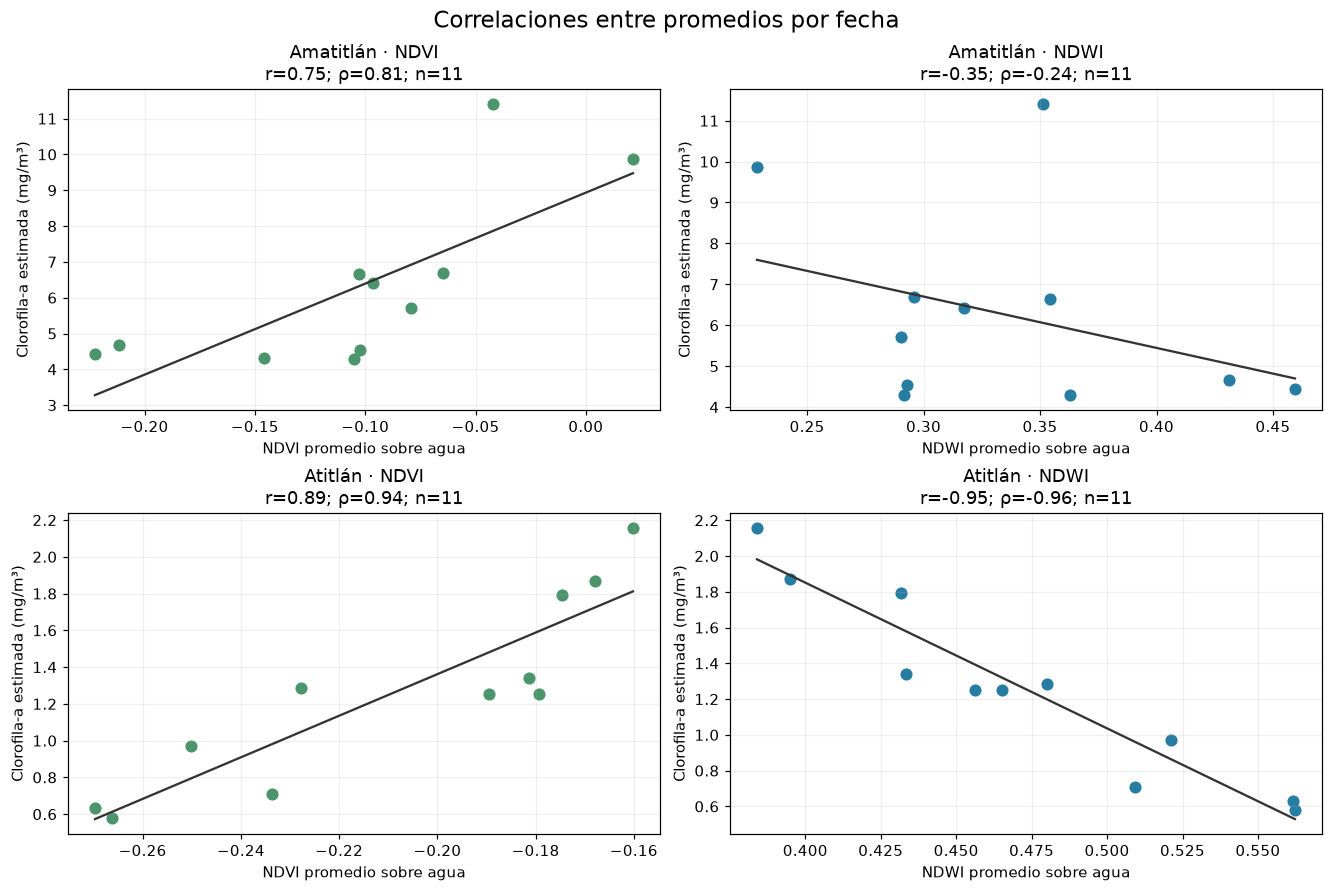

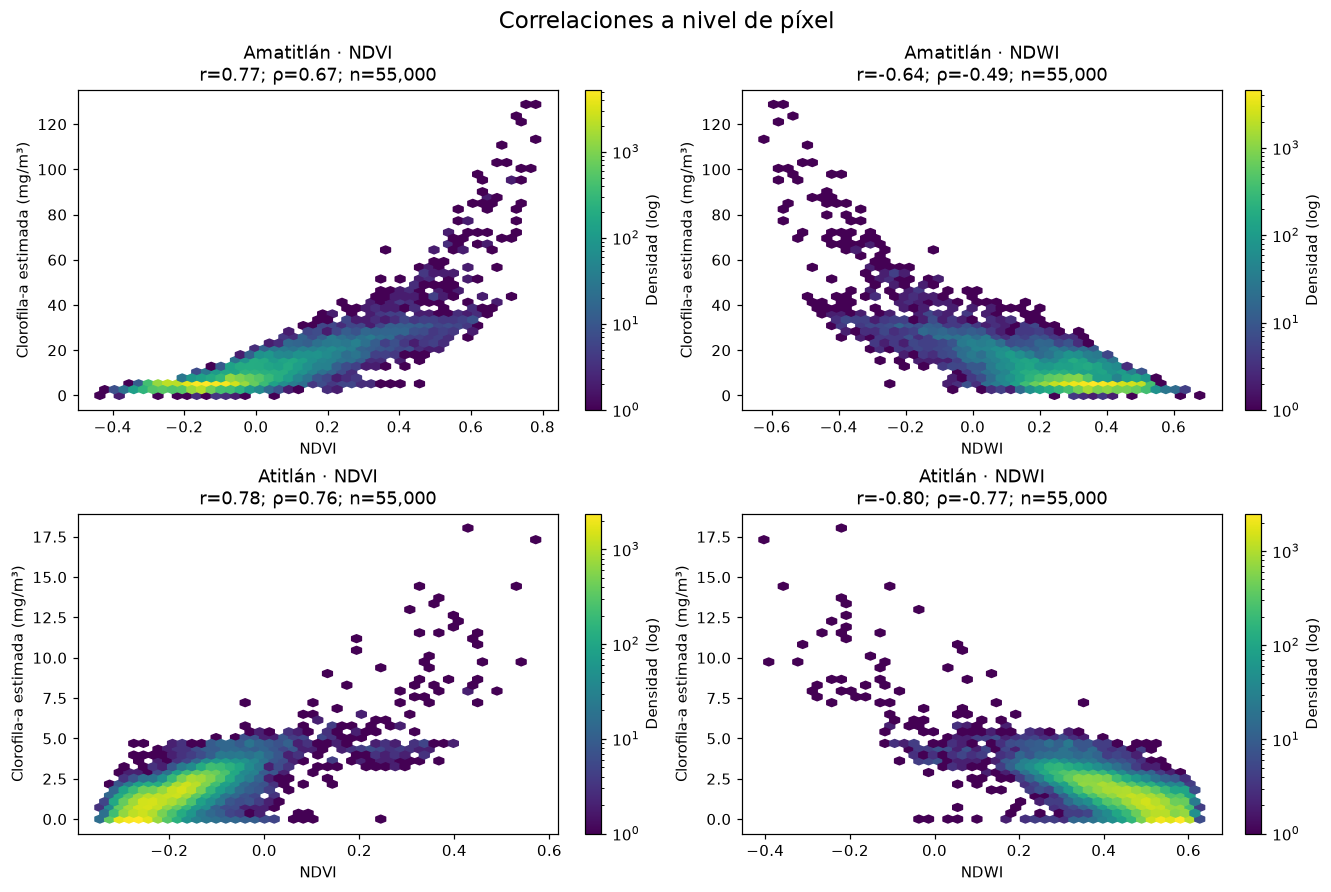

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for row_index, (lake_id, group) in enumerate(summary.groupby("lago_id", sort=True)):
    for column_index, (variable, column, color) in enumerate((
        ("NDVI", "ndvi_promedio_agua", "#4c956c"),
        ("NDWI", "ndwi_promedio_agua", "#277da1"),
    )):
        ax = axes[row_index, column_index]
        ax.scatter(group[column], group["cyano_promedio_mg_m3"], s=48, color=color)
        fit = np.polyfit(group[column], group["cyano_promedio_mg_m3"], 1)
        line_x = np.linspace(group[column].min(), group[column].max(), 100)
        ax.plot(line_x, np.polyval(fit, line_x), color="#333333")
        row = correlations[
            (correlations["lago_id"] == lake_id)
            & (correlations["nivel"] == "promedios temporales")
            & (correlations["variable"] == variable)
        ].iloc[0]
        ax.set_title(f"{LAKES[lake_id]['name']} · {variable}\nr={row.pearson_r:.2f}; ρ={row.spearman_rho:.2f}; n=11")
        ax.set_xlabel(f"{variable} promedio sobre agua")
        ax.set_ylabel("Clorofila-a estimada (mg/m³)")
        ax.grid(alpha=0.2)
fig.suptitle("Correlaciones entre promedios por fecha", fontsize=15)
fig.savefig(RESULTS_DIR / "06_correlaciones_temporales.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for row_index, lake_id in enumerate(sorted(pooled_samples)):
    cyano = np.concatenate(pooled_samples[lake_id]["cyano"])
    for column_index, variable in enumerate(("NDVI", "NDWI")):
        values = np.concatenate(pooled_samples[lake_id][variable])
        ax = axes[row_index, column_index]
        density = ax.hexbin(values, cyano, gridsize=45, bins="log", mincnt=1, cmap="viridis")
        row = correlations[
            (correlations["lago_id"] == lake_id)
            & (correlations["nivel"] == "píxeles muestreados")
            & (correlations["variable"] == variable)
        ].iloc[0]
        ax.set_title(f"{LAKES[lake_id]['name']} · {variable}\nr={row.pearson_r:.2f}; ρ={row.spearman_rho:.2f}; n={row.n:,}")
        ax.set_xlabel(variable); ax.set_ylabel("Clorofila-a estimada (mg/m³)")
        fig.colorbar(density, ax=ax, label="Densidad (log)")
fig.suptitle("Correlaciones a nivel de píxel", fontsize=15)
fig.savefig(RESULTS_DIR / "06_correlaciones_pixeles.png", dpi=180, bbox_inches="tight")
plt.show()

**Interpretación.** NDVI se correlacionó positivamente con el estimador (r temporal de 0.75 en Amatitlán y 0.89 en Atitlán). NDWI mostró una relación negativa débil en Amatitlán (−0.35) y muy fuerte en Atitlán (−0.95). Estas asociaciones son espectrales y **no demuestran causalidad**: los índices comparten bandas, la muestra usa la misma máscara y existe autocorrelación espacial.